# 02 — Model Training
**Project:** Lightweight IDS for Raspberry Pi (SAG-DRDO Internship)  
**Reference:** Musthafa et al., IEEE Access 2025  

**What this notebook does:**
1. Loads preprocessed arrays from `artifacts/` (output of `01_data_preprocessing.ipynb`)
2. Defines the Stacked LSTM architecture (paper-aligned)
3. Trains with BCEWithLogitsLoss + Adam + ReduceLROnPlateau
4. Plots loss & accuracy curves
5. Saves the trained model for pruning/quantization in notebook 03

**Inputs needed:**
```
artifacts/X_train.npy
artifacts/X_test.npy
artifacts/y_train.npy
artifacts/y_test.npy
```

**Outputs saved:**
```
artifacts/
  ids_model.pth          # full-precision trained model weights
  ids_model_scripted.pt  # TorchScript version (portable)
  training_history.json  # loss & accuracy per epoch
  training_curves.png
```

## 1. Imports

In [32]:
import os
import json
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')

Device : cpu
PyTorch: 2.8.0+cpu


## 2. Config

In [33]:
BASE_DIR      = "../"
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')

# ── Hyperparameters ───────────────────────────────────────────────────────────
INPUT_SIZE  = 36        # ANOVA-selected features (fixed by notebook 01)
HIDDEN_SIZE = 128       # paper uses 128
NUM_LAYERS  = 2         # stacked LSTM depth
DROPOUT     = 0.4
BATCH_SIZE  = 1024
EPOCHS      = 30
LR          = 1e-3
# ─────────────────────────────────────────────────────────────────────────────

print('Config set ✓')
print(f'Artifacts dir: {ARTIFACTS_DIR}')

Config set ✓
Artifacts dir: ../artifacts


## 3. Load Preprocessed Data

In [34]:
X_train = np.load(os.path.join(ARTIFACTS_DIR, 'X_train.npy'))  # (82332, 36) float32
X_test  = np.load(os.path.join(ARTIFACTS_DIR, 'X_test.npy'))   # (175341, 36) float32
y_train = np.load(os.path.join(ARTIFACTS_DIR, 'y_train.npy'))  # (82332,) int
y_test  = np.load(os.path.join(ARTIFACTS_DIR, 'y_test.npy'))   # (175341,) int

print(f'X_train : {X_train.shape}  dtype={X_train.dtype}')
print(f'X_test  : {X_test.shape}  dtype={X_test.dtype}')
print(f'y_train : {y_train.shape}  attack rate={y_train.mean()*100:.1f}%')
print(f'y_test  : {y_test.shape}  attack rate={y_test.mean()*100:.1f}%')

X_train : (82332, 36)  dtype=float32
X_test  : (175341, 36)  dtype=float32
y_train : (82332,)  attack rate=55.1%
y_test  : (175341,)  attack rate=68.1%


In [35]:
# Build PyTorch datasets
# LSTM expects input shape: (batch, seq_len, features)
# We treat each network record as a single time-step → seq_len = 1

X_tr_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # (N, 1, 36)
y_tr_t = torch.tensor(y_train, dtype=torch.float32)               # (N,)
X_te_t = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)  # (N, 1, 36)
y_te_t = torch.tensor(y_test,  dtype=torch.float32)               # (N,)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=(device.type == 'cuda')
)
test_loader = DataLoader(
    TensorDataset(X_te_t, y_te_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=(device.type == 'cuda')
)

print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')
print(f'Input shape   : {next(iter(train_loader))[0].shape}')  # (1024, 1, 36)

Train batches : 81
Test  batches : 172
Input shape   : torch.Size([1024, 1, 36])


## 4. Model Architecture — Stacked LSTM

```
Input  : (batch, seq_len=1, features=36)
  │
  ▼
LSTM   : input=36 → hidden=128, 2 layers, dropout=0.3
  │  (take last time-step output)
  ▼
BatchNorm1D(128)
  │
  ▼
Dropout(0.3)
  │
  ▼
Linear(128 → 1)   ← raw logit
  │
  ▼
Sigmoid           ← probability (applied at inference, not during training)
```

In [36]:
class StackedLSTM(nn.Module):
    """
    2-layer stacked LSTM binary classifier.
    Architecture from Musthafa et al. (IEEE Access 2025).
    """
    def __init__(
        self,
        input_size:  int = 36,
        hidden_size: int = 128,
        num_layers:  int = 2,
        dropout:     float = 0.4
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout          # applied between LSTM layers
        )
        self.bn   = nn.BatchNorm1d(hidden_size)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len=1, input_size)
        out, _ = self.lstm(x)        # out: (batch, seq_len, hidden_size)
        out    = out[:, -1, :]       # last time-step: (batch, hidden_size)
        out    = self.bn(out)
        out    = self.drop(out)
        return self.fc(out).squeeze(1)   # raw logit: (batch,)


model = StackedLSTM(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

print(model)
print()

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_kb   = total_params * 4 / 1024   # float32 = 4 bytes

print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Estimated size      : {model_size_kb:.1f} KB (float32)')

StackedLSTM(
  (lstm): LSTM(36, 128, num_layers=2, batch_first=True, dropout=0.4)
  (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters    : 217,473
Trainable parameters: 217,473
Estimated size      : 849.5 KB (float32)


## 5. Training Loop

In [37]:
criterion = nn.BCEWithLogitsLoss()   # numerically stable sigmoid + BCE combined
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

best_val_acc  = 0.0
best_epoch    = 0
training_start = time.time()

print(f'Training on {device} | Epochs={EPOCHS} | Batch={BATCH_SIZE} | LR={LR}')
print('-' * 72)
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>8} | {"LR":>8}')
print('-' * 72)

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        t_loss    += loss.item() * len(yb)
        preds      = (torch.sigmoid(logits) > 0.5).float()
        t_correct += (preds == yb).sum().item()
        t_total   += len(yb)

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0

    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits  = model(Xb)
            v_loss += criterion(logits, yb).item() * len(yb)
            preds   = (torch.sigmoid(logits) > 0.5).float()
            v_correct += (preds == yb).sum().item()
            v_total   += len(yb)

    # ── Metrics ───────────────────────────────────────────────────────────────
    t_loss /= t_total;  v_loss /= v_total
    t_acc   = t_correct / t_total * 100
    v_acc   = v_correct / v_total * 100
    cur_lr  = optimizer.param_groups[0]['lr']

    history['train_loss'].append(round(t_loss, 6))
    history['val_loss'].append(round(v_loss, 6))
    history['train_acc'].append(round(t_acc, 4))
    history['val_acc'].append(round(v_acc, 4))

    scheduler.step(v_loss)

    # Log LR reduction manually (verbose removed in PyTorch 2.4+)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != cur_lr:
        print(f'  ↓ LR reduced: {cur_lr:.6f} → {new_lr:.6f}')

    # Track best
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_epoch   = epoch
        torch.save(model.state_dict(), os.path.join(ARTIFACTS_DIR, 'ids_model_best.pth'))

    elapsed = time.time() - epoch_start
    print(
        f'{epoch:>6} | {t_loss:>10.4f} | {t_acc:>8.2f}% | '
        f'{v_loss:>8.4f} | {v_acc:>7.2f}% | {cur_lr:>8.6f}  [{elapsed:.1f}s]'
    )

total_time = time.time() - training_start
print('-' * 72)
print(f'Training complete in {total_time/60:.1f} min')
print(f'Best val accuracy : {best_val_acc:.4f}%  (epoch {best_epoch})')

Training on cpu | Epochs=30 | Batch=1024 | LR=0.001
------------------------------------------------------------------------
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |       LR
------------------------------------------------------------------------
     1 |     0.3342 |    84.20% |   0.2666 |   88.53% | 0.001000  [7.6s]
     2 |     0.2423 |    89.21% |   0.2970 |   87.40% | 0.001000  [6.3s]
     3 |     0.2200 |    90.58% |   0.2958 |   88.03% | 0.001000  [5.1s]
     4 |     0.2040 |    91.42% |   0.3169 |   87.46% | 0.001000  [5.0s]
  ↓ LR reduced: 0.001000 → 0.000500
     5 |     0.1909 |    91.97% |   0.3071 |   88.22% | 0.001000  [5.1s]
     6 |     0.1804 |    92.50% |   0.3207 |   87.57% | 0.000500  [5.0s]
     7 |     0.1795 |    92.56% |   0.3362 |   86.75% | 0.000500  [5.1s]
     8 |     0.1757 |    92.68% |   0.3275 |   87.43% | 0.000500  [4.9s]
  ↓ LR reduced: 0.000500 → 0.000250
     9 |     0.1712 |    92.97% |   0.2833 |   89.14% | 0.000500  [7.0s]
    10 |

## 6. Training Curves

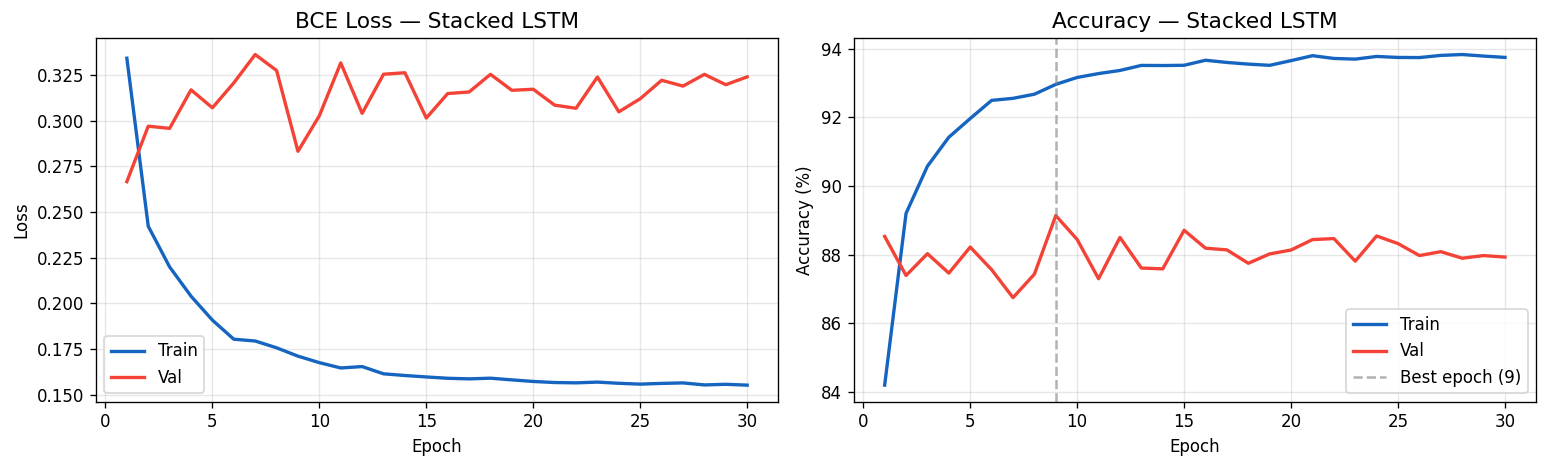

Final train acc  : 93.7509%
Final val   acc  : 87.9321%
Overfitting gap  : 5.8188%  (paper reports 0.22%)


In [38]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(epochs_range, history['train_loss'], color='#1565C0', label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   color='#F44336', label='Val',   linewidth=2)
axes[0].set_title('BCE Loss — Stacked LSTM')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], color='#1565C0', label='Train', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   color='#F44336', label='Val',   linewidth=2)
axes[1].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Best epoch ({best_epoch})')
axes[1].set_title('Accuracy — Stacked LSTM')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'training_curves.png'), bbox_inches='tight')
plt.show()

overfit_gap = history['train_acc'][-1] - history['val_acc'][-1]
print(f'Final train acc  : {history["train_acc"][-1]:.4f}%')
print(f'Final val   acc  : {history["val_acc"][-1]:.4f}%')
print(f'Overfitting gap  : {overfit_gap:.4f}%  (paper reports 0.22%)')

## 7. Save Model & History

In [39]:
# Load best weights back into model before saving final
model.load_state_dict(
    torch.load(os.path.join(ARTIFACTS_DIR, 'ids_model_best.pth'), map_location='cpu')
)
model.eval()
print(f'Best weights loaded (epoch {best_epoch}) ✓')

# 1. Save state_dict (standard PyTorch — used by notebook 03 for pruning)
torch.save(
    {
        'model_state_dict' : model.state_dict(),
        'hyperparams'      : {
            'input_size' : INPUT_SIZE,
            'hidden_size': HIDDEN_SIZE,
            'num_layers' : NUM_LAYERS,
            'dropout'    : DROPOUT
        },
        'best_val_acc' : best_val_acc,
        'best_epoch'   : best_epoch
    },
    os.path.join(ARTIFACTS_DIR, 'ids_model.pth')
)
print('ids_model.pth saved ✓')

# 2. TorchScript — portable, no class definition needed at load time
dummy_input   = torch.zeros(1, 1, INPUT_SIZE)   # (batch=1, seq=1, features=36)
scripted_model = torch.jit.trace(model.cpu(), dummy_input)
scripted_model.save(os.path.join(ARTIFACTS_DIR, 'ids_model_scripted.pt'))
print('ids_model_scripted.pt saved ✓')

# 3. Training history
history['best_val_acc'] = best_val_acc
history['best_epoch']   = best_epoch
with open(os.path.join(ARTIFACTS_DIR, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print('training_history.json saved ✓')

Best weights loaded (epoch 9) ✓
ids_model.pth saved ✓
ids_model_scripted.pt saved ✓
training_history.json saved ✓


In [40]:
# File sizes
print('=== Artifacts ===')
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    fpath = os.path.join(ARTIFACTS_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f'  {fname:<35} {size:>8.1f} KB')

=== Artifacts ===
  X_test.npy                           24657.5 KB
  X_train.npy                          11578.1 KB
  anova_feature_ranking.png               95.3 KB
  anova_ranking.csv                        1.7 KB
  class_distribution.png                  43.3 KB
  ids_model.pth                          856.0 KB
  ids_model_best.pth                     855.9 KB
  ids_model_scripted.pt                  866.0 KB
  label_encoders.pkl                       1.5 KB
  pca_visualization.png                   74.5 KB
  scaler.pkl                               2.0 KB
  selected_features.json                   0.5 KB
  training_curves.png                     89.5 KB
  training_history.json                    1.8 KB
  y_test.npy                            1370.0 KB
  y_train.npy                            643.3 KB


## 8. Quick Inference Test

Verify the model predicts correctly on a few samples before moving to pruning.

In [41]:
model.eval()

# Grab 8 samples — 4 normal, 4 attack
normal_idx = np.where(y_test == 0)[0][:4]
attack_idx = np.where(y_test == 1)[0][:4]
sample_idx = np.concatenate([normal_idx, attack_idx])

X_sample = torch.tensor(X_test[sample_idx], dtype=torch.float32).unsqueeze(1)  # (8, 1, 36)
y_sample = y_test[sample_idx]

with torch.no_grad():
    logits = model(X_sample)
    probs  = torch.sigmoid(logits).numpy()
    preds  = (probs > 0.5).astype(int)

print(f'{"Sample":>7} | {"True Label":>12} | {"Predicted":>10} | {"Confidence":>11} | {"Correct":>7}')
print('-' * 60)
for i, (true, pred, prob) in enumerate(zip(y_sample, preds, probs)):
    true_name = 'Normal' if true == 0 else 'Attack'
    pred_name = 'Normal' if pred == 0 else 'Attack'
    correct   = '✓' if true == pred else '✗'
    print(f'{i+1:>7} | {true_name:>12} | {pred_name:>10} | {prob:>10.4f}  | {correct:>7}')

 Sample |   True Label |  Predicted |  Confidence | Correct
------------------------------------------------------------
      1 |       Normal |     Attack |     0.9567  |       ✗
      2 |       Normal |     Attack |     1.0000  |       ✗
      3 |       Normal |     Attack |     1.0000  |       ✗
      4 |       Normal |     Attack |     0.9958  |       ✗
      5 |       Attack |     Attack |     0.6597  |       ✓
      6 |       Attack |     Attack |     0.7390  |       ✓
      7 |       Attack |     Normal |     0.4546  |       ✗
      8 |       Attack |     Attack |     0.7294  |       ✓


## 9. Summary

In [42]:
pth_size_kb = os.path.getsize(os.path.join(ARTIFACTS_DIR, 'ids_model.pth')) / 1024

print('=' * 55)
print('  TRAINING SUMMARY')
print('=' * 55)
print(f'  Architecture  : Stacked LSTM (2 layers, hidden=128)')
print(f'  Total params  : {total_params:,}')
print(f'  Model size    : {pth_size_kb:.1f} KB (float32)')
print(f'  Epochs        : {EPOCHS}')
print(f'  Best epoch    : {best_epoch}')
print(f'  Best val acc  : {best_val_acc:.4f}%')
print(f'  Overfitting   : {overfit_gap:.4f}%')
print(f'  Training time : {total_time/60:.1f} min  (on {device})')
print('=' * 55)
print()
print('  Next notebook → 03_pruning_quantization.ipynb')
print('  Goal: compress this model for Raspberry Pi deployment')

  TRAINING SUMMARY
  Architecture  : Stacked LSTM (2 layers, hidden=128)
  Total params  : 217,473
  Model size    : 856.0 KB (float32)
  Epochs        : 30
  Best epoch    : 9
  Best val acc  : 89.1423%
  Overfitting   : 5.8188%
  Training time : 2.9 min  (on cpu)

  Next notebook → 03_pruning_quantization.ipynb
  Goal: compress this model for Raspberry Pi deployment
